# Bank Transaction Fraud Detection
### End-to-End ML Pipeline — Real Indian Banking Data

---

**Dataset**: Real bank transaction records (Indian banking, INR)  
**Target**: `Is_Fraud` (0 = legitimate, 1 = fraud)  
**Challenge**: Highly imbalanced classes + rich mixed-type features (numeric, categorical, text)

**Pipeline overview**:
1. EDA on real schema (23 columns)
2. Datetime feature extraction from `Transaction_Date` + `Transaction_Time`
3. Categorical encoding + demographic features
4. **NLP on `Transaction_Description`** — keyword risk scoring + TF-IDF
5. Amount & balance anomaly features + cross-feature interactions
6. Baseline XGBoost (no imbalance handling) — the *before* state
7. Three imbalance strategies: `scale_pos_weight`, SMOTE, ADASYN
8. Threshold optimisation
9. **SHAP explainability** — global + local (waterfall per transaction)
10. Cross-validation + business impact analysis

## 0. Setup

In [1]:
import sys, warnings, os
warnings.filterwarnings('ignore')
sys.path.insert(0, 'src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    precision_score, recall_score, confusion_matrix, precision_recall_curve
)
from imblearn.over_sampling import SMOTE, ADASYN
import xgboost as xgb
import shap

from data_generator import generate_dataset, load_real_data, TARGET_COL, RAW_FEATURE_COLS
from feature_engineering import engineer_features, get_numeric_feature_cols
from nlp_features import add_keyword_features, TFIDFFraudFeatures
from evaluation import full_report, find_optimal_threshold, plot_comparison, plot_pr_roc_curves, plot_confusion_matrices

os.makedirs('plots', exist_ok=True)
os.makedirs('models', exist_ok=True)
SEED = 42
np.random.seed(SEED)
print('Setup complete.')

Setup complete.


In [2]:
print("TARGET_COL =", TARGET_COL)
print("RAW_FEATURE_COLS =", RAW_FEATURE_COLS)

TARGET_COL = Is_Fraud
RAW_FEATURE_COLS = ['Gender', 'Age', 'State', 'Account_Type', 'Transaction_Date', 'Transaction_Time', 'Transaction_Amount', 'Transaction_Type', 'Merchant_Category', 'Account_Balance', 'Transaction_Device', 'Transaction_Location', 'Device_Type', 'Transaction_Description']


## 1. Load Data

In [3]:
# ── To use your real dataset, replace the line below: ──────────────────────
# df = load_real_data('data/your_dataset.csv')

# ── Synthetic demo data (same schema as your real data) ──────────────────────
import pandas as pd

df = pd.read_csv(
    r"C:\Users\Ishika\Downloads\bank_fraud_detection\data\Bank_Transaction_Fraud_Detection.csv"
)

print(f'Shape: {df.shape}')
print("\nColumns:")
print(df.columns.tolist())
print(df['Is_Fraud'].value_counts())

df.head(3)

Shape: (200000, 24)

Columns:
['Customer_ID', 'Customer_Name', 'Gender', 'Age', 'State', 'City', 'Bank_Branch', 'Account_Type', 'Transaction_ID', 'Transaction_Date', 'Transaction_Time', 'Transaction_Amount', 'Merchant_ID', 'Transaction_Type', 'Merchant_Category', 'Account_Balance', 'Transaction_Device', 'Transaction_Location', 'Device_Type', 'Is_Fraud', 'Transaction_Currency', 'Customer_Contact', 'Transaction_Description', 'Customer_Email']
Is_Fraud
0    189912
1     10088
Name: count, dtype: int64


,Customer_ID,Customer_Name,Gender,Age,State,City,Bank_Branch,Account_Type,Transaction_ID,Transaction_Date,...,Merchant_Category,Account_Balance,Transaction_Device,Transaction_Location,Device_Type,Is_Fraud,Transaction_Currency,Customer_Contact,Transaction_Description,Customer_Email
0,d5f6ec07-d69e-4f47-b9b4-7c58ff17c19e,Osha Tella,Male,60,Kerala,Thiruvananthapuram,Thiruvananthapuram Branch,Savings,4fa3208f-9e23-42dc-b330-844829d0c12c,23-01-2025,...,Restaurant,74557.27,Voice Assistant,"Thiruvananthapuram, Kerala",POS,0,INR,+9198579XXXXXX,Bitcoin transaction,oshaXXXXX@XXXXX.com
1,7c14ad51-781a-4db9-b7bd-67439c175262,Hredhaan Khosla,Female,51,Maharashtra,Nashik,Nashik Branch,Business,c9de0c06-2c4c-40a9-97ed-3c7b8f97c79c,11-01-2025,...,Restaurant,74622.66,POS Mobile Device,"Nashik, Maharashtra",Desktop,0,INR,+9191074XXXXXX,Grocery delivery,hredhaanXXXX@XXXXXX.com
2,3a73a0e5-d4da-45aa-85f3-528413900a35,Ekani Nazareth,Male,20,Bihar,Bhagalpur,Bhagalpur Branch,Savings,e41c55f9-c016-4ff3-872b-cae72467c75c,25-01-2025,...,Groceries,66817.99,ATM,"Bhagalpur, Bihar",Desktop,0,INR,+9197745XXXXXX,Mutual fund investment,ekaniXXX@XXXXXX.com


## 2. Exploratory Data Analysis

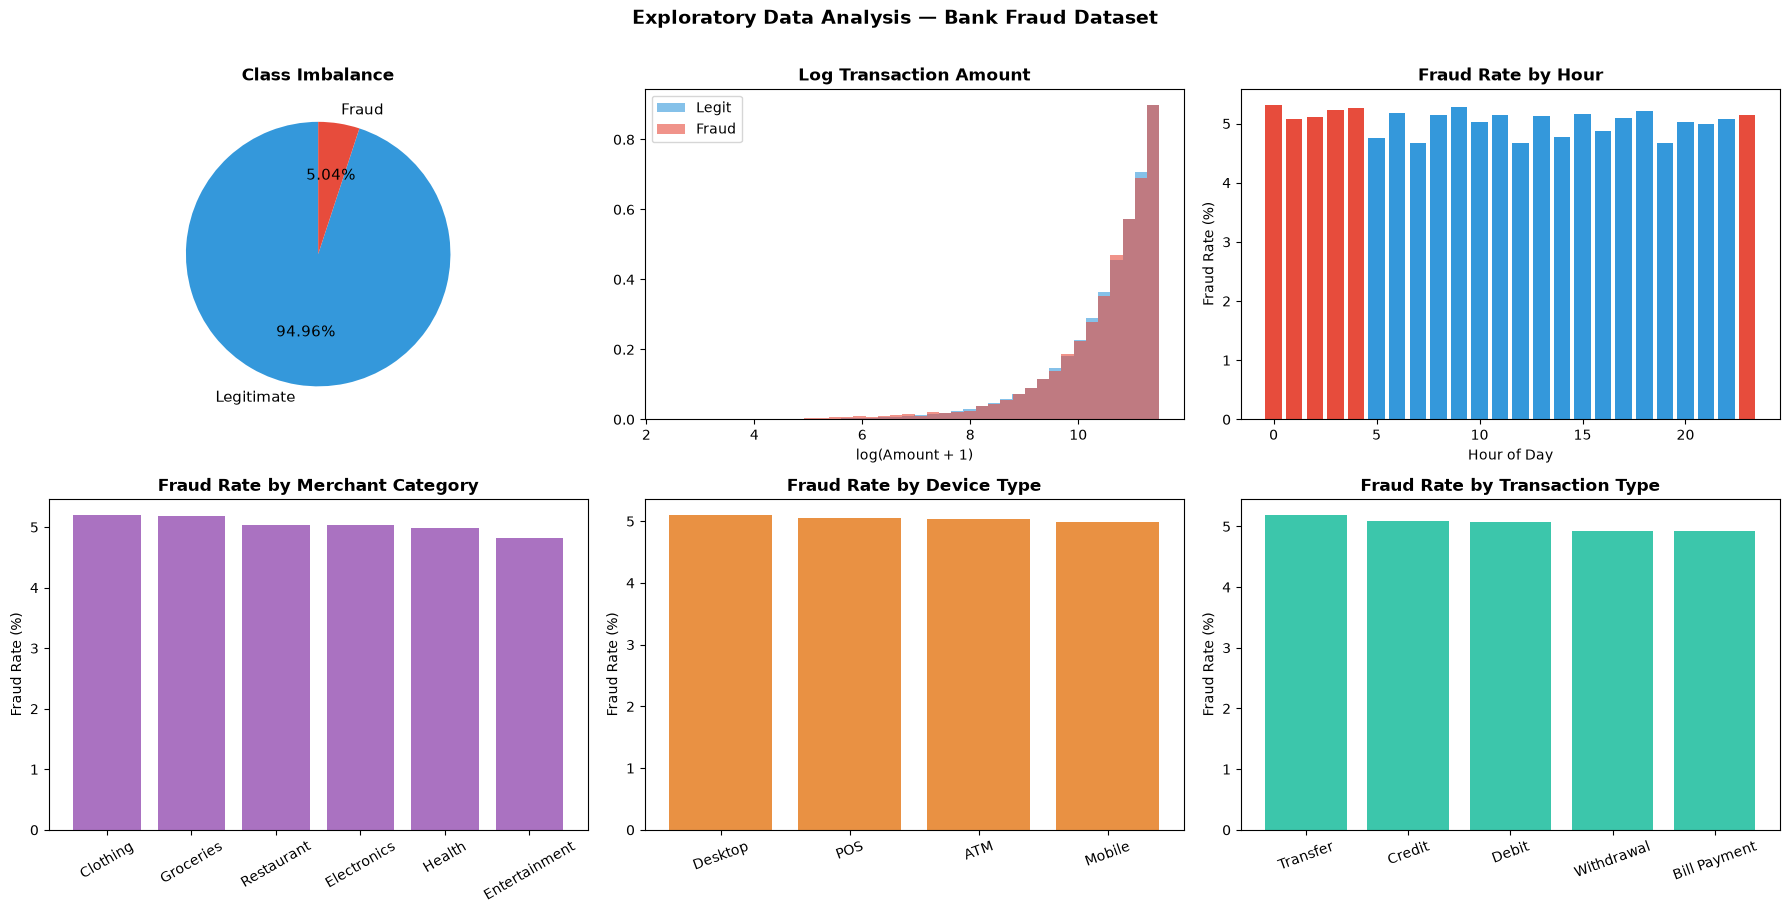

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

# 1. Class imbalance
vc = df[TARGET_COL].value_counts()
axes[0].pie([vc[0], vc[1]], labels=['Legitimate', 'Fraud'],
            autopct='%1.2f%%', colors=['#3498DB', '#E74C3C'],
            startangle=90, textprops={'fontsize': 11})
axes[0].set_title('Class Imbalance', fontweight='bold')

# 2. Transaction Amount by class
for lbl, col, name in [(0,'#3498DB','Legit'),(1,'#E74C3C','Fraud')]:
    axes[1].hist(np.log1p(df[df[TARGET_COL]==lbl]['Transaction_Amount']),
                 bins=40, alpha=0.6, color=col, label=name, density=True)
axes[1].set_title('Log Transaction Amount', fontweight='bold')
axes[1].set_xlabel('log(Amount + 1)'); axes[1].legend()

# 3. Hour-of-day fraud rate
df['_hour'] = pd.to_datetime(df['Transaction_Time'], format='%H:%M:%S', errors='coerce').dt.hour
hourly = df.groupby('_hour')[TARGET_COL].mean() * 100
axes[2].bar(hourly.index, hourly.values,
            color=['#E74C3C' if h in [0,1,2,3,4,23] else '#3498DB' for h in hourly.index])
axes[2].set_title('Fraud Rate by Hour', fontweight='bold')
axes[2].set_xlabel('Hour of Day'); axes[2].set_ylabel('Fraud Rate (%)')

# 4. Merchant category fraud rate
cat_fraud = df.groupby('Merchant_Category')[TARGET_COL].mean().sort_values(ascending=False)
axes[3].bar(cat_fraud.index, cat_fraud.values * 100, color='#9B59B6', alpha=0.85)
axes[3].set_title('Fraud Rate by Merchant Category', fontweight='bold')
axes[3].set_ylabel('Fraud Rate (%)'); axes[3].tick_params(axis='x', rotation=30)

# 5. Device type fraud rate
dev_fraud = df.groupby('Device_Type')[TARGET_COL].mean().sort_values(ascending=False)
axes[4].bar(dev_fraud.index, dev_fraud.values * 100, color='#E67E22', alpha=0.85)
axes[4].set_title('Fraud Rate by Device Type', fontweight='bold')
axes[4].set_ylabel('Fraud Rate (%)'); axes[4].tick_params(axis='x', rotation=20)

# 6. Transaction type fraud rate
txn_fraud = df.groupby('Transaction_Type')[TARGET_COL].mean().sort_values(ascending=False)
axes[5].bar(txn_fraud.index, txn_fraud.values * 100, color='#1ABC9C', alpha=0.85)
axes[5].set_title('Fraud Rate by Transaction Type', fontweight='bold')
axes[5].set_ylabel('Fraud Rate (%)'); axes[5].tick_params(axis='x', rotation=20)

df.drop(columns=['_hour'], inplace=True)
plt.suptitle('Exploratory Data Analysis — Bank Fraud Dataset', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plots/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. NLP — Transaction Description Analysis

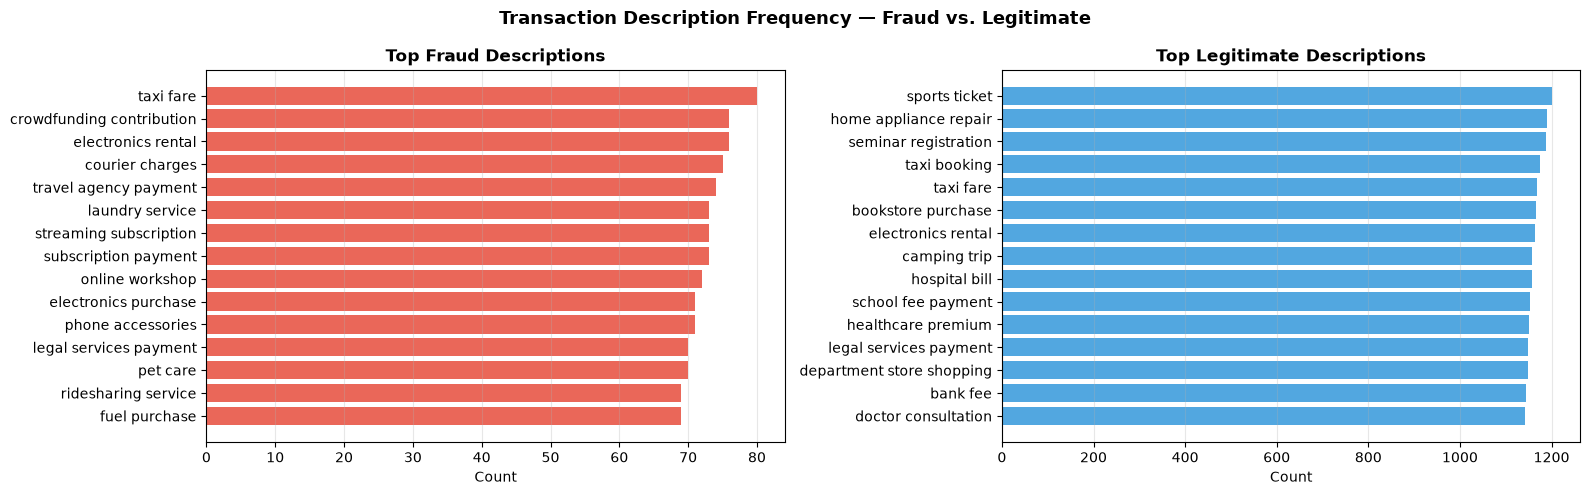

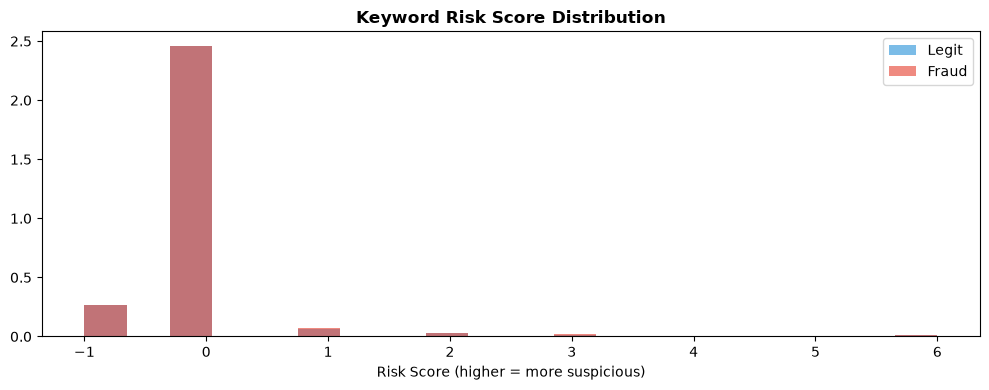

In [5]:
# Most common descriptions in fraud vs. legit
from collections import Counter

def top_desc(df, label, n=15):
    texts = df[df[TARGET_COL] == label]['Transaction_Description'].dropna().str.lower()
    return Counter(texts).most_common(n)

fraud_top  = top_desc(df, 1)
legit_top  = top_desc(df, 0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, data, title, color in [
    (axes[0], fraud_top,  'Top Fraud Descriptions',      '#E74C3C'),
    (axes[1], legit_top,  'Top Legitimate Descriptions',  '#3498DB'),
]:
    labels, counts = zip(*data)
    ax.barh(labels[::-1], counts[::-1], color=color, alpha=0.85)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel('Count')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Transaction Description Frequency — Fraud vs. Legitimate',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/nlp_description_freq.png', dpi=150, bbox_inches='tight')
plt.show()

# Keyword risk score distribution
from nlp_features import keyword_risk_score
df['_risk'] = df['Transaction_Description'].apply(keyword_risk_score)
fig, ax = plt.subplots(figsize=(10, 4))
for lbl, col, name in [(0,'#3498DB','Legit'),(1,'#E74C3C','Fraud')]:
    scores = df[df[TARGET_COL]==lbl]['_risk']
    ax.hist(scores, bins=20, alpha=0.65, color=col, label=name, density=True)
ax.set_title('Keyword Risk Score Distribution', fontweight='bold')
ax.set_xlabel('Risk Score (higher = more suspicious)'); ax.legend()
plt.tight_layout()
plt.savefig('plots/nlp_risk_score_dist.png', dpi=150, bbox_inches='tight')
plt.show()
df.drop(columns=['_risk'], inplace=True)

## 4. Feature Engineering

In [6]:
# Step 1: Structured feature engineering
df_eng = engineer_features(df)

# Step 2: Keyword NLP features
df_eng = add_keyword_features(df_eng, desc_col='Transaction_Description')

# Step 3: TF-IDF (fit on full data for demo; in production fit only on train split)
tfidf = TFIDFFraudFeatures(max_features=30)

# We'll do the TF-IDF split-aware below, here just preview
print('Engineered dataframe shape:', df_eng.shape)

numeric_cols = get_numeric_feature_cols(df_eng)
print(f'\nNumeric features ({len(numeric_cols)}):')
for i, c in enumerate(numeric_cols):
    print(f'  [{i:2d}] {c}')

Engineered dataframe shape: (200000, 63)

Numeric features (38):
  [ 0] Age
  [ 1] Transaction_Amount
  [ 2] Account_Balance
  [ 3] txn_is_night
  [ 4] txn_is_weekend
  [ 5] txn_is_month_end
  [ 6] gender_enc
  [ 7] account_type_enc
  [ 8] device_type_enc
  [ 9] transaction_type_enc
  [10] merchant_cat_enc
  [11] is_high_risk_device
  [12] state_freq
  [13] log_amount
  [14] log_balance
  [15] amount_to_balance
  [16] balance_after
  [17] would_overdraft
  [18] amount_gt_half_bal
  [19] log_balance_after
  [20] age_group
  [21] is_senior
  [22] is_young
  [23] night_x_high_amount
  [24] night_x_transfer
  [25] mobile_x_high_amount
  [26] risk_device_x_amount
  [27] weekend_x_withdrawal
  [28] young_x_high_amount
  [29] overdraft_x_night
  [30] desc_risk_score
  [31] desc_has_transfer
  [32] desc_has_crypto
  [33] desc_has_cash
  [34] desc_has_online
  [35] desc_has_overseas
  [36] desc_word_count
  [37] desc_is_generic


## 5. Train / Test Split

In [7]:
y = df_eng[TARGET_COL].values

# ── TF-IDF: fit on train descriptions only ────────────────────────────────────
train_idx, test_idx = train_test_split(
    np.arange(len(df_eng)), test_size=0.2, random_state=SEED, stratify=y
)

tfidf = TFIDFFraudFeatures(max_features=30)
tfidf_train = tfidf.fit_transform(df_eng['Transaction_Description'].iloc[train_idx])
tfidf_test  = tfidf.transform(df_eng['Transaction_Description'].iloc[test_idx])

tfidf_train.index = df_eng.index[train_idx]
tfidf_test.index  = df_eng.index[test_idx]

# ── Combine structured + TF-IDF features ─────────────────────────────────────
numeric_cols = get_numeric_feature_cols(df_eng)
tfidf_cols   = tfidf_train.columns.tolist()
all_feature_cols = numeric_cols + tfidf_cols

X_struct  = df_eng[numeric_cols].copy()
X_full    = pd.concat([X_struct, pd.concat([tfidf_train, tfidf_test]).sort_index()], axis=1)

X_train   = X_full.iloc[train_idx].values
X_test    = X_full.iloc[test_idx].values
y_train   = y[train_idx]
y_test    = y[test_idx]

neg, pos  = np.bincount(y_train)
scale_pos_weight = neg / pos

print(f'Train: {X_train.shape}, fraud: {pos:,}')
print(f'Test:  {X_test.shape}')
print(f'scale_pos_weight: {scale_pos_weight:.1f}')
print(f'Total features: {len(all_feature_cols)}  ({len(numeric_cols)} structured + {len(tfidf_cols)} TF-IDF)')

Train: (160000, 68), fraud: 8,070
Test:  (40000, 68)
scale_pos_weight: 18.8
Total features: 68  (38 structured + 30 TF-IDF)


## 6. Baseline XGBoost (No Imbalance Handling)

In [8]:
baseline = xgb.XGBClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.1,
    use_label_encoder=False, eval_metric='logloss',
    random_state=SEED, n_jobs=-1,
)
baseline.fit(X_train, y_train)

y_prob_baseline = baseline.predict_proba(X_test)[:, 1]
y_pred_baseline = baseline.predict(X_test)
results_baseline = full_report(y_test, y_pred_baseline, y_prob_baseline,
                               'Baseline XGBoost (no imbalance handling)')


  Baseline XGBoost (no imbalance handling)
  ROC-AUC              0.5090
  PR-AUC               0.0524
  F1 (fraud)           0.0000
  Precision            0.0000
  Recall               0.0000
  Accuracy             0.9495

              precision    recall  f1-score   support

       Legit       0.95      1.00      0.97     37982
       Fraud       0.00      0.00      0.00      2018

    accuracy                           0.95     40000
   macro avg       0.47      0.50      0.49     40000
weighted avg       0.90      0.95      0.92     40000



## 7. Strategy 1 — `scale_pos_weight`

In [9]:
xgb_weighted = xgb.XGBClassifier(
    n_estimators=300, max_depth=7, learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8, colsample_bytree=0.8,
    min_child_weight=5, gamma=1, reg_alpha=0.1, reg_lambda=1,
    use_label_encoder=False, eval_metric='aucpr',
    random_state=SEED, n_jobs=-1,
)
xgb_weighted.fit(X_train, y_train)

y_prob_weighted = xgb_weighted.predict_proba(X_test)[:, 1]
thresh_weighted = find_optimal_threshold(y_train, xgb_weighted.predict_proba(X_train)[:, 1])
y_pred_weighted = (y_prob_weighted >= thresh_weighted).astype(int)
print(f'Optimal threshold: {thresh_weighted:.3f}')
results_weighted = full_report(y_test, y_pred_weighted, y_prob_weighted,
                               'XGBoost + scale_pos_weight + Threshold Tuning')

Optimal threshold: 0.563

  XGBoost + scale_pos_weight + Threshold Tuning
  ROC-AUC              0.5022
  PR-AUC               0.0520
  F1 (fraud)           0.0513
  Precision            0.0633
  Recall               0.0431
  Accuracy             0.9195

              precision    recall  f1-score   support

       Legit       0.95      0.97      0.96     37982
       Fraud       0.06      0.04      0.05      2018

    accuracy                           0.92     40000
   macro avg       0.51      0.50      0.50     40000
weighted avg       0.91      0.92      0.91     40000



## 8. Strategy 2 — SMOTE

In [10]:
smote = SMOTE(sampling_strategy=0.1, random_state=SEED)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
neg_sm, pos_sm = np.bincount(y_train_sm)
print(f'After SMOTE: Legit {neg_sm:,}, Fraud {pos_sm:,}')

xgb_smote = xgb.XGBClassifier(
    n_estimators=300, max_depth=7, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    min_child_weight=3, gamma=0.5, reg_alpha=0.1,
    use_label_encoder=False, eval_metric='aucpr',
    random_state=SEED, n_jobs=-1,
)
xgb_smote.fit(X_train_sm, y_train_sm)

y_prob_smote = xgb_smote.predict_proba(X_test)[:, 1]
thresh_smote = find_optimal_threshold(y_train_sm, xgb_smote.predict_proba(X_train_sm)[:, 1])
y_pred_smote = (y_prob_smote >= thresh_smote).astype(int)
print(f'Optimal threshold: {thresh_smote:.3f}')
results_smote = full_report(y_test, y_pred_smote, y_prob_smote,
                            'XGBoost + SMOTE + Threshold Tuning')

After SMOTE: Legit 151,930, Fraud 15,193
Optimal threshold: 0.090

  XGBoost + SMOTE + Threshold Tuning
  ROC-AUC              0.5119
  PR-AUC               0.0534
  F1 (fraud)           0.0315
  Precision            0.0698
  Recall               0.0203
  Accuracy             0.9369

              precision    recall  f1-score   support

       Legit       0.95      0.99      0.97     37982
       Fraud       0.07      0.02      0.03      2018

    accuracy                           0.94     40000
   macro avg       0.51      0.50      0.50     40000
weighted avg       0.91      0.94      0.92     40000



## 9. Strategy 3 — ADASYN

In [11]:
adasyn = ADASYN(sampling_strategy=0.1, random_state=SEED)
X_train_ada, y_train_ada = adasyn.fit_resample(X_train, y_train)
neg_ada, pos_ada = np.bincount(y_train_ada)
print(f'After ADASYN: Legit {neg_ada:,}, Fraud {pos_ada:,}')

xgb_adasyn = xgb.XGBClassifier(
    n_estimators=300, max_depth=7, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    min_child_weight=3, gamma=0.5, reg_alpha=0.1,
    use_label_encoder=False, eval_metric='aucpr',
    random_state=SEED, n_jobs=-1,
)
xgb_adasyn.fit(X_train_ada, y_train_ada)

y_prob_adasyn = xgb_adasyn.predict_proba(X_test)[:, 1]
thresh_adasyn = find_optimal_threshold(y_train_ada, xgb_adasyn.predict_proba(X_train_ada)[:, 1])
y_pred_adasyn = (y_prob_adasyn >= thresh_adasyn).astype(int)
print(f'Optimal threshold: {thresh_adasyn:.3f}')
results_adasyn = full_report(y_test, y_pred_adasyn, y_prob_adasyn,
                             'XGBoost + ADASYN + Threshold Tuning')

After ADASYN: Legit 151,930, Fraud 16,133
Optimal threshold: 0.092

  XGBoost + ADASYN + Threshold Tuning
  ROC-AUC              0.5186
  PR-AUC               0.0547
  F1 (fraud)           0.0311
  Precision            0.0726
  Recall               0.0198
  Accuracy             0.9378

              precision    recall  f1-score   support

       Legit       0.95      0.99      0.97     37982
       Fraud       0.07      0.02      0.03      2018

    accuracy                           0.94     40000
   macro avg       0.51      0.50      0.50     40000
weighted avg       0.91      0.94      0.92     40000



## 10. Comparison — Before vs. After

In [12]:
print("results_baseline exists:", 'results_baseline' in globals())
print("results_weighted exists:", 'results_weighted' in globals())
print("results_smote exists:", 'results_smote' in globals())
print("results_adasyn exists:", 'results_adasyn' in globals())
print("xgb_weighted exists:", 'xgb_weighted' in globals())
print("y_prob_weighted exists:", 'y_prob_weighted' in globals())
print("y_pred_weighted exists:", 'y_pred_weighted' in globals())

results_baseline exists: True
results_weighted exists: True
results_smote exists: True
results_adasyn exists: True
xgb_weighted exists: True
y_prob_weighted exists: True
y_pred_weighted exists: True



METRICS COMPARISON
                  ROC-AUC  PR-AUC  F1 (fraud)  Precision  Recall  Accuracy
Baseline           0.5090  0.0524      0.0000     0.0000  0.0000    0.9495
scale_pos_weight   0.5022  0.0520      0.0513     0.0633  0.0431    0.9196
SMOTE              0.5119  0.0534      0.0315     0.0698  0.0203    0.9369
ADASYN             0.5186  0.0547      0.0311     0.0726  0.0198    0.9378


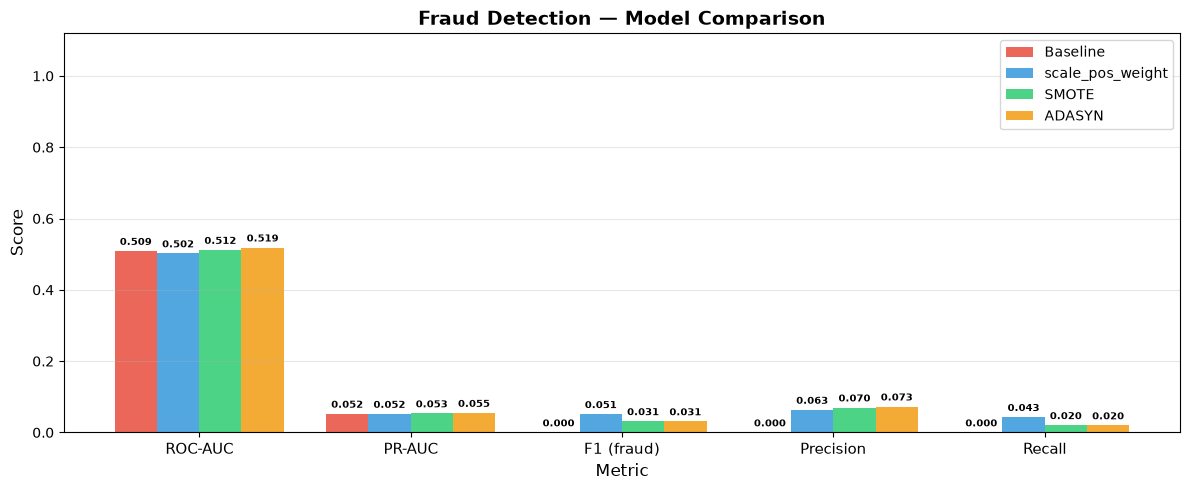

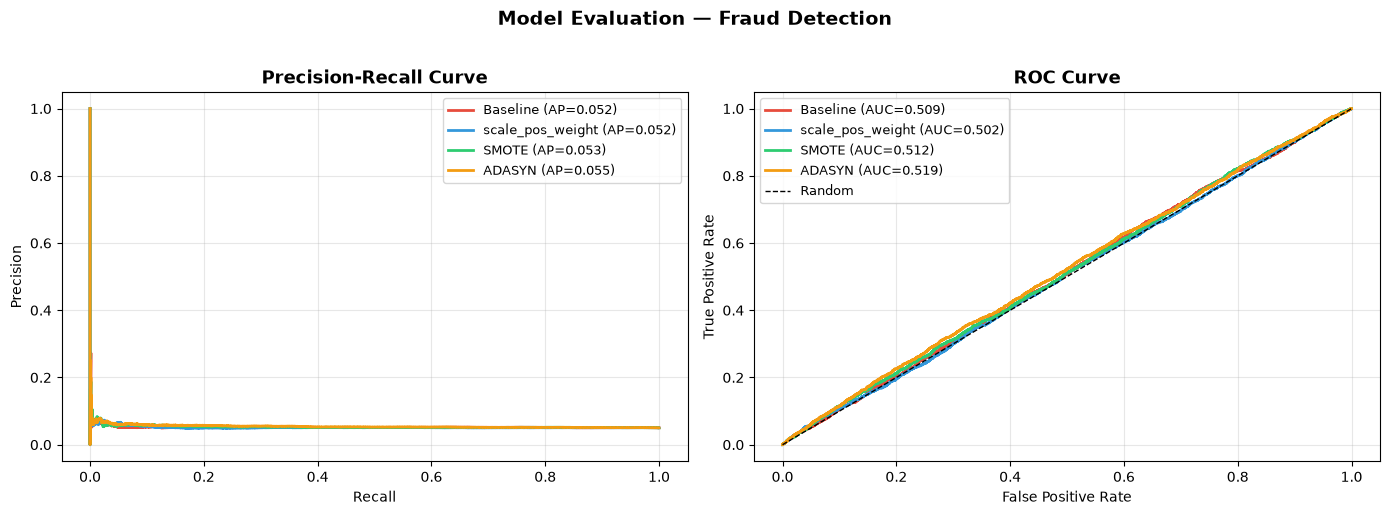

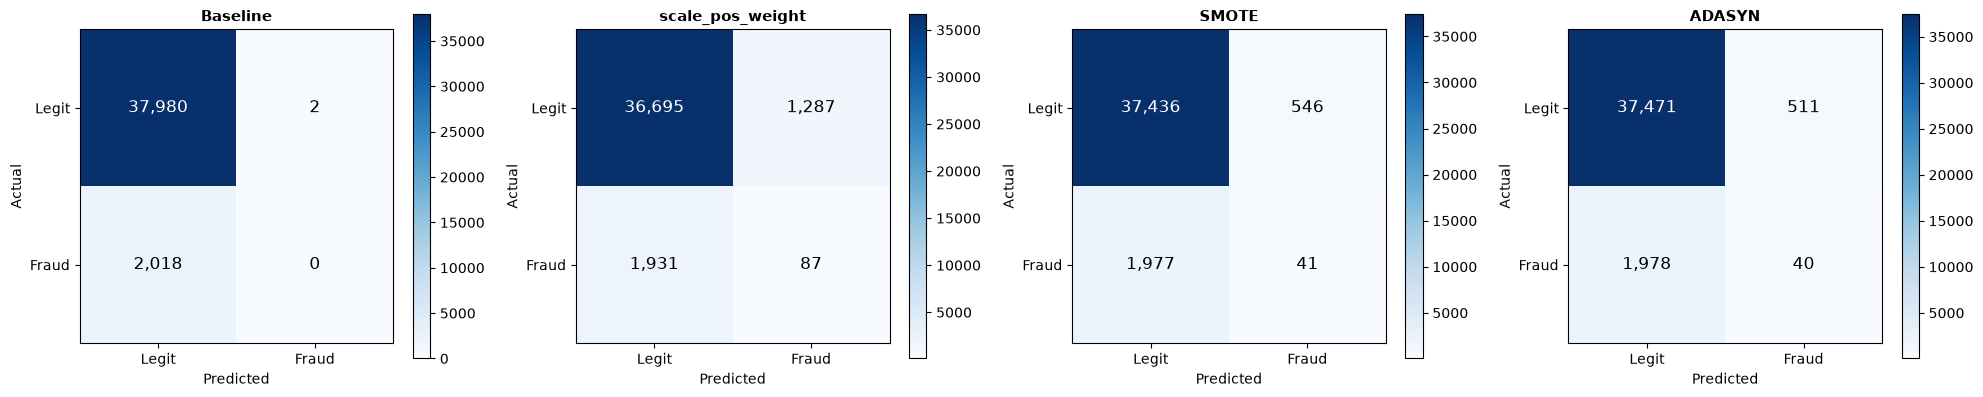

In [13]:
all_results = {
    'Baseline':          results_baseline,
    'scale_pos_weight':  results_weighted,
    'SMOTE':             results_smote,
    'ADASYN':            results_adasyn,
}
comparison_df = pd.DataFrame(all_results).T[['ROC-AUC','PR-AUC','F1 (fraud)','Precision','Recall','Accuracy']]
print('\n' + '='*70)
print('METRICS COMPARISON')
print('='*70)
print(comparison_df.round(4).to_string())

plot_comparison(all_results, save_path='plots/metrics_comparison.png')

curve_data = {
    'Baseline':         (y_test, y_prob_baseline),
    'scale_pos_weight': (y_test, y_prob_weighted),
    'SMOTE':            (y_test, y_prob_smote),
    'ADASYN':           (y_test, y_prob_adasyn),
}
plot_pr_roc_curves(curve_data, save_path='plots/pr_roc_curves.png')

cm_data = {
    'Baseline':         (y_test, y_pred_baseline),
    'scale_pos_weight': (y_test, y_pred_weighted),
    'SMOTE':            (y_test, y_pred_smote),
    'ADASYN':           (y_test, y_pred_adasyn),
}
plot_confusion_matrices(cm_data, save_path='plots/confusion_matrices.png')

## 11. Feature Importance

Best model: ADASYN  (PR-AUC=0.0547)


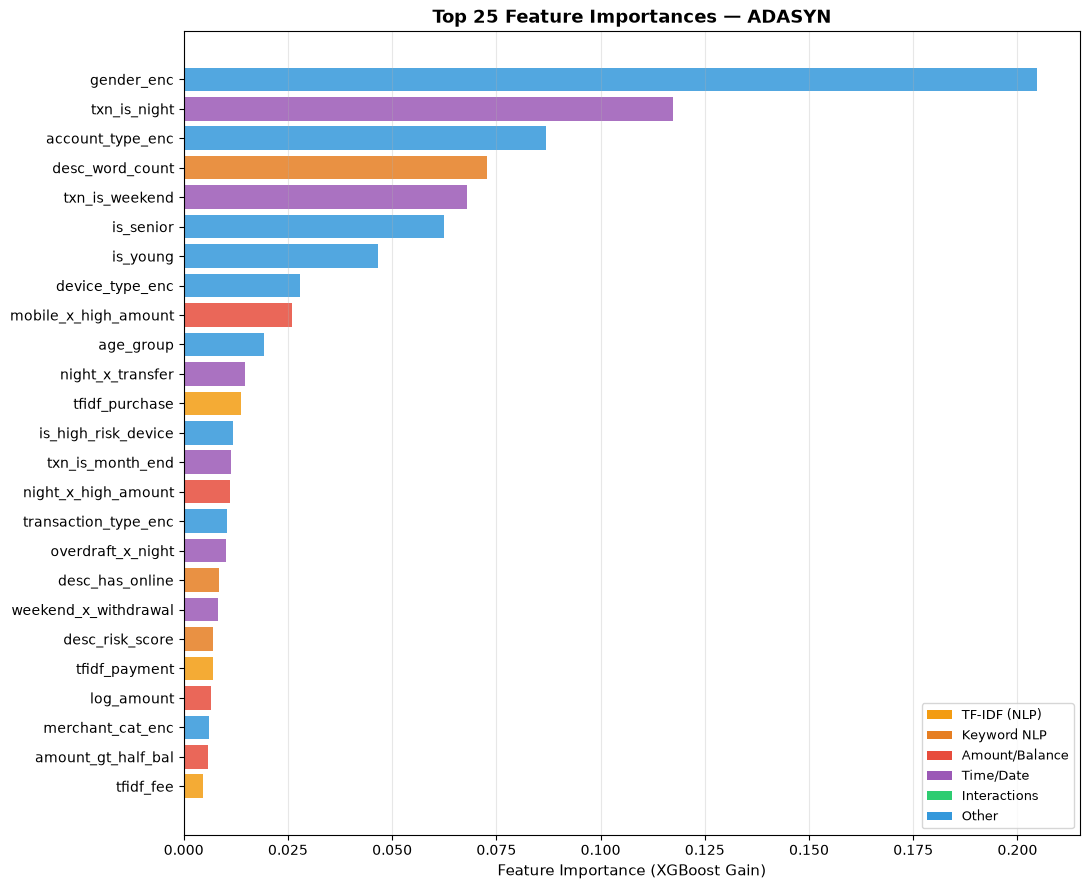

In [14]:
best_name = max(all_results, key=lambda k: all_results[k]['PR-AUC'])
model_map = {
    'Baseline':         (baseline,     y_prob_baseline),
    'scale_pos_weight': (xgb_weighted, y_prob_weighted),
    'SMOTE':            (xgb_smote,    y_prob_smote),
    'ADASYN':           (xgb_adasyn,   y_prob_adasyn),
}
best_model, best_prob = model_map[best_name]
print(f'Best model: {best_name}  (PR-AUC={all_results[best_name]["PR-AUC"]:.4f})')

importances = best_model.feature_importances_
feat_imp = pd.DataFrame({'feature': all_feature_cols, 'importance': importances})
feat_imp = feat_imp.sort_values('importance', ascending=True).tail(25)

def feat_color(f):
    if f.startswith('tfidf_'):   return '#F39C12'   # NLP features — orange
    if 'desc_' in f:             return '#E67E22'   # keyword NLP — dark orange
    if any(x in f for x in ['amount','balance','log']): return '#E74C3C'  # amount — red
    if any(x in f for x in ['night','hour','day','weekend','month']): return '#9B59B6'  # time — purple
    if 'x_' in f:                return '#2ECC71'   # interactions — green
    return '#3498DB'                                # other — blue

colors = [feat_color(f) for f in feat_imp['feature']]
fig, ax = plt.subplots(figsize=(11, 9))
ax.barh(feat_imp['feature'], feat_imp['importance'], color=colors, alpha=0.85)
ax.set_xlabel('Feature Importance (XGBoost Gain)', fontsize=11)
ax.set_title(f'Top 25 Feature Importances — {best_name}', fontsize=13, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#F39C12', label='TF-IDF (NLP)'),
    Patch(facecolor='#E67E22', label='Keyword NLP'),
    Patch(facecolor='#E74C3C', label='Amount/Balance'),
    Patch(facecolor='#9B59B6', label='Time/Date'),
    Patch(facecolor='#2ECC71', label='Interactions'),
    Patch(facecolor='#3498DB', label='Other'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('plots/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. SHAP — Model Explainability

SHAP answers *why* the model flagged a specific transaction.  
In Indian banking, regulators and customers both require this justification.

In [15]:
shap.initjs()
sample_idx  = np.random.choice(len(X_test), size=min(1500, len(X_test)), replace=False)
X_shap      = X_test[sample_idx]
y_shap      = y_test[sample_idx]

explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_shap)
print(f'SHAP values computed for {len(X_shap)} transactions.')

SHAP values computed for 1500 transactions.


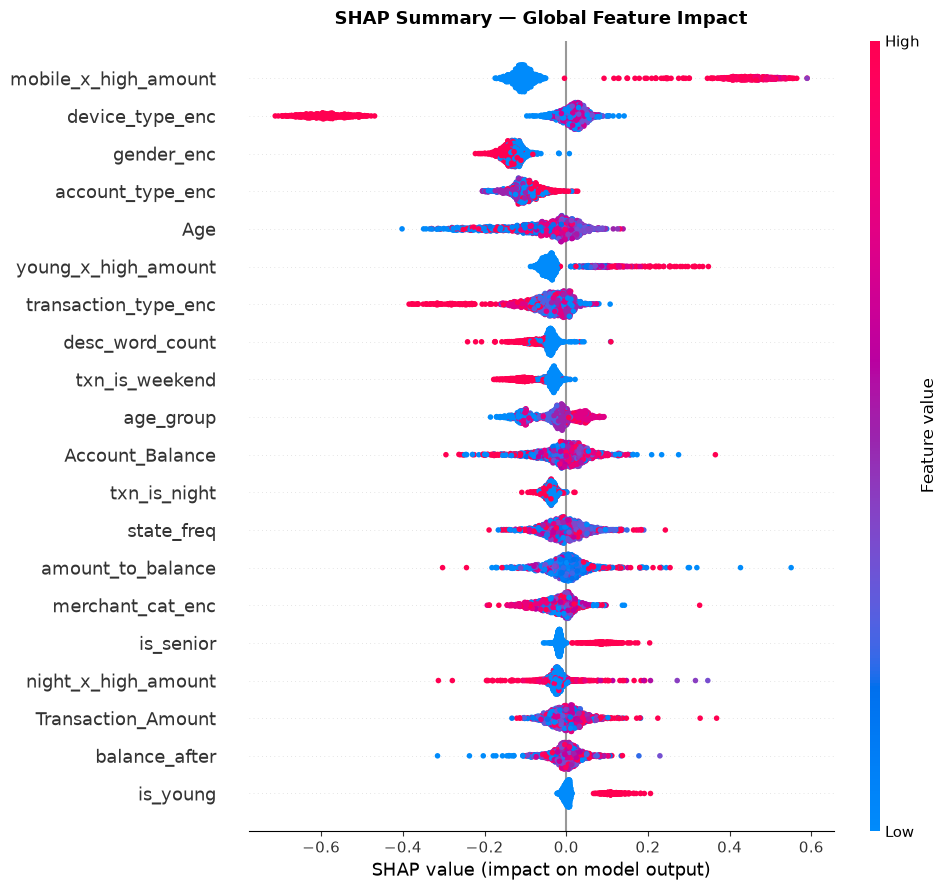

In [16]:
# SHAP Summary — Beeswarm
fig, ax = plt.subplots(figsize=(10, 9))
shap.summary_plot(shap_values, X_shap, feature_names=all_feature_cols,
                  max_display=20, show=False, plot_size=None)
plt.title('SHAP Summary — Global Feature Impact', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('plots/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

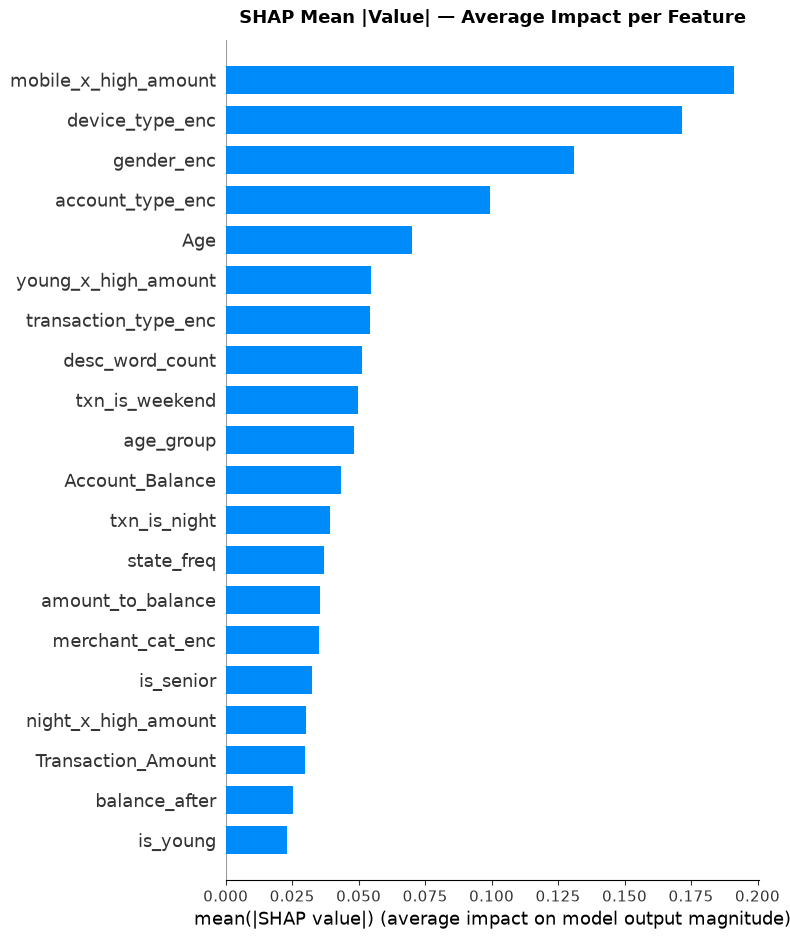

In [17]:
# SHAP Bar — Mean |SHAP| ranking
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap, feature_names=all_feature_cols,
                  plot_type='bar', max_display=20, show=False)
plt.title('SHAP Mean |Value| — Average Impact per Feature', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('plots/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

Explaining transaction #1454  |  Predicted fraud probability: 0.1088


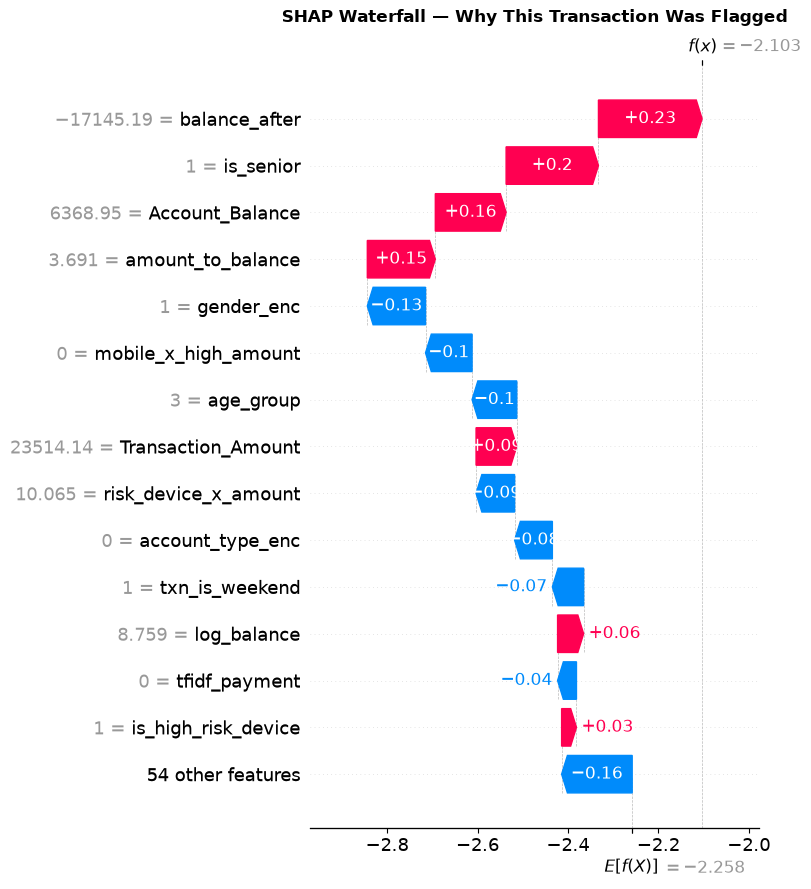

In [18]:
# SHAP Waterfall — Explain one fraud transaction
fraud_idx_in_shap = np.where(y_shap == 1)[0]
top_fraud = fraud_idx_in_shap[
    np.argmax(best_model.predict_proba(X_shap[fraud_idx_in_shap])[:, 1])
]
prob = best_model.predict_proba(X_shap[[top_fraud]])[:, 1][0]
print(f'Explaining transaction #{top_fraud}  |  Predicted fraud probability: {prob:.4f}')

explanation = shap.Explanation(
    values=shap_values[top_fraud],
    base_values=explainer.expected_value,
    data=X_shap[top_fraud],
    feature_names=all_feature_cols,
)
fig, ax = plt.subplots(figsize=(10, 7))
shap.waterfall_plot(explanation, max_display=15, show=False)
plt.title('SHAP Waterfall — Why This Transaction Was Flagged', fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('plots/shap_waterfall_fraud.png', dpi=150, bbox_inches='tight')
plt.show()

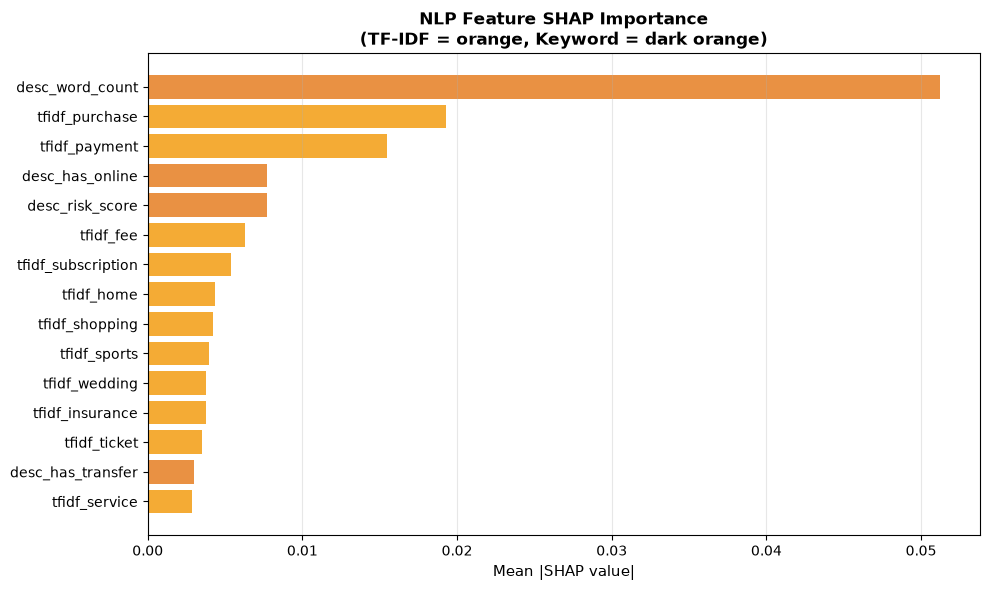

In [19]:
# NLP feature SHAP focus — how TF-IDF + keyword scores drive predictions
nlp_indices = [i for i, f in enumerate(all_feature_cols)
               if f.startswith('tfidf_') or 'desc_' in f]
nlp_names   = [all_feature_cols[i] for i in nlp_indices]
nlp_shap    = shap_values[:, nlp_indices]

nlp_imp = np.abs(nlp_shap).mean(axis=0)
order   = np.argsort(nlp_imp)[::-1][:15]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh([nlp_names[i] for i in order[::-1]], nlp_imp[order[::-1]],
        color=['#F39C12' if nlp_names[i].startswith('tfidf_') else '#E67E22'
               for i in order[::-1]], alpha=0.85)
ax.set_xlabel('Mean |SHAP value|', fontsize=11)
ax.set_title('NLP Feature SHAP Importance\n(TF-IDF = orange, Keyword = dark orange)',
             fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('plots/shap_nlp_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Threshold Sensitivity Analysis

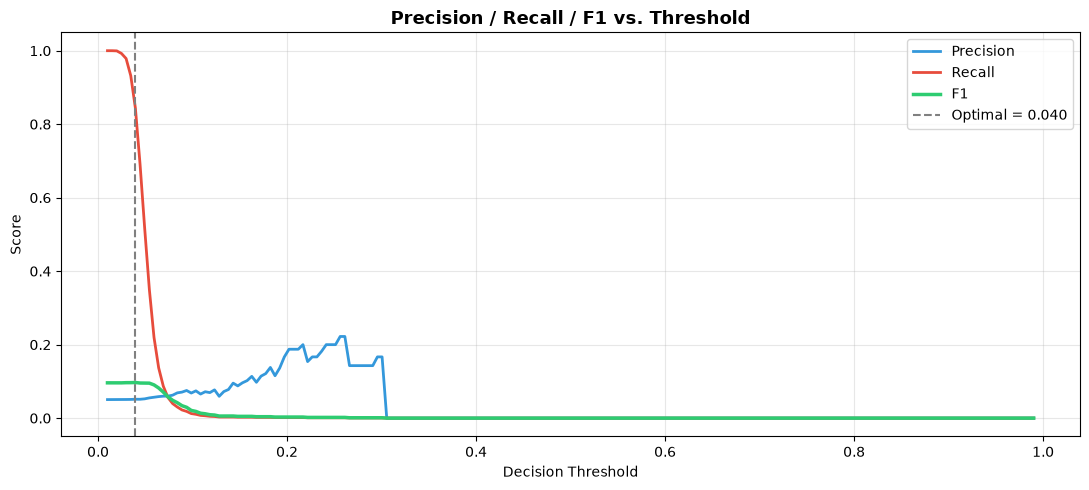

Optimal threshold: 0.040  →  P=0.051, R=0.843, F1=0.097


In [20]:
thresholds = np.linspace(0.01, 0.99, 200)
precisions, recalls, f1s = [], [], []
for t in thresholds:
    pred = (best_prob >= t).astype(int)
    precisions.append(precision_score(y_test, pred, zero_division=0))
    recalls.append(recall_score(y_test, pred, zero_division=0))
    f1s.append(f1_score(y_test, pred, zero_division=0))
best_t_idx = np.argmax(f1s)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(thresholds, precisions, '#3498DB', lw=2, label='Precision')
ax.plot(thresholds, recalls,    '#E74C3C', lw=2, label='Recall')
ax.plot(thresholds, f1s,        '#2ECC71', lw=2.5, label='F1')
ax.axvline(thresholds[best_t_idx], color='gray', ls='--', lw=1.5,
           label=f'Optimal = {thresholds[best_t_idx]:.3f}')
ax.set_xlabel('Decision Threshold'); ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 vs. Threshold', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/threshold_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Optimal threshold: {thresholds[best_t_idx]:.3f}  →  '
      f'P={precisions[best_t_idx]:.3f}, R={recalls[best_t_idx]:.3f}, F1={f1s[best_t_idx]:.3f}')

## 14. Cross-Validation

5-Fold Stratified Cross-Validation
ROC-AUC:  0.4950 ± 0.0063
PR-AUC:   0.0505 ± 0.0009
F1 Score: 0.0799 ± 0.0018


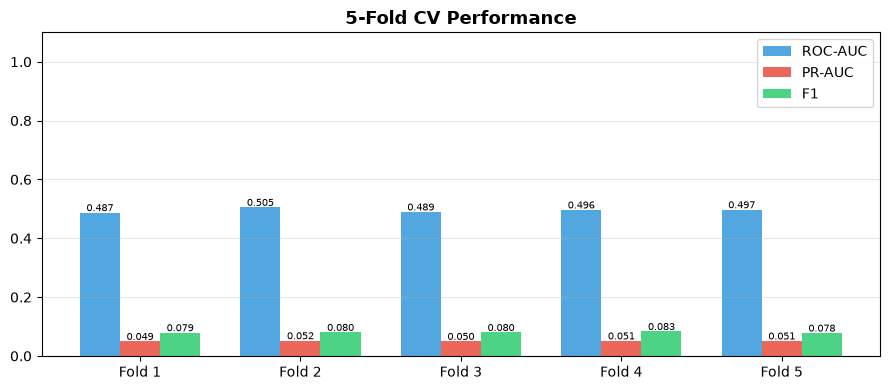

In [21]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=7, learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8, colsample_bytree=0.8,
    min_child_weight=5, gamma=1, reg_alpha=0.1,
    eval_metric='aucpr', use_label_encoder=False,
    random_state=SEED, n_jobs=-1,
)
X_all = X_full.values
y_all = df_eng[TARGET_COL].values

roc_scores = cross_val_score(cv_model, X_all, y_all, cv=cv, scoring='roc_auc', n_jobs=-1)
pr_scores  = cross_val_score(cv_model, X_all, y_all, cv=cv, scoring='average_precision', n_jobs=-1)
f1_cv      = cross_val_score(cv_model, X_all, y_all, cv=cv, scoring='f1', n_jobs=-1)

print('5-Fold Stratified Cross-Validation')
print('=' * 45)
print(f'ROC-AUC:  {roc_scores.mean():.4f} ± {roc_scores.std():.4f}')
print(f'PR-AUC:   {pr_scores.mean():.4f} ± {pr_scores.std():.4f}')
print(f'F1 Score: {f1_cv.mean():.4f} ± {f1_cv.std():.4f}')

fig, ax = plt.subplots(figsize=(9, 4))
x, w = np.arange(5), 0.25
ax.bar(x-w, roc_scores, w, label='ROC-AUC', color='#3498DB', alpha=0.85)
ax.bar(x,   pr_scores,  w, label='PR-AUC',  color='#E74C3C', alpha=0.85)
ax.bar(x+w, f1_cv,      w, label='F1',       color='#2ECC71', alpha=0.85)
for sc, off in [(roc_scores,-w),(pr_scores,0),(f1_cv,w)]:
    for i,v in enumerate(sc):
        ax.text(i+off, v+0.005, f'{v:.3f}', ha='center', fontsize=7)
ax.set_xticks(x); ax.set_xticklabels([f'Fold {i+1}' for i in range(5)])
ax.set_ylim(0, 1.1); ax.set_title('5-Fold CV Performance', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plots/cv_scores.png', dpi=150, bbox_inches='tight')
plt.show()

## 15. Business Impact Analysis

In [23]:
# Adjust these to match your bank's actual cost model
AVG_FRAUD_AMOUNT_INR = 55_000   # avg fraudulent transaction (INR)
FALSE_POSITIVE_COST  = 200      # friction cost per blocked legit txn (INR)
MISSED_FRAUD_COST    = 55_000   # full loss per missed fraud (INR)

def business_impact(y_true, y_pred, avg_fraud, fp_cost, fn_cost):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    recovered  = tp * avg_fraud
    missed     = fn * fn_cost
    fa_cost    = fp * fp_cost
    net        = recovered - missed - fa_cost
    return {'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
            'Recovered (INR)': f'₹{recovered:,.0f}',
            'Missed (INR)':    f'₹{missed:,.0f}',
            'False Alerts (INR)': f'₹{fa_cost:,.0f}',
            'Net Benefit (INR)':  f'₹{net:,.0f}'}

best_labels = (best_prob >= thresholds[best_t_idx]).astype(int)

print('BASELINE')
for k,v in business_impact(y_test, y_pred_baseline,
                            AVG_FRAUD_AMOUNT_INR, FALSE_POSITIVE_COST, MISSED_FRAUD_COST).items():
    print(f'  {k:<25} {v}')

print(f'\nBEST MODEL ({best_name})')
for k,v in business_impact(y_test, best_labels,
                            AVG_FRAUD_AMOUNT_INR, FALSE_POSITIVE_COST, MISSED_FRAUD_COST).items():
    print(f'  {k:<25} {v}')

BASELINE
  TP                        0
  FP                        2
  FN                        2018
  TN                        37980
  Recovered (INR)           ₹0
  Missed (INR)              ₹110,990,000
  False Alerts (INR)        ₹400
  Net Benefit (INR)         ₹-110,990,400

BEST MODEL (ADASYN)
  TP                        1702
  FP                        31398
  FN                        316
  TN                        6584
  Recovered (INR)           ₹93,610,000
  Missed (INR)              ₹17,380,000
  False Alerts (INR)        ₹6,279,600
  Net Benefit (INR)         ₹69,950,400


## 16. Save Model

In [24]:
import pickle, json

with open('models/fraud_detector_final.pkl', 'wb') as f:
    pickle.dump(best_model, f)
with open('models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

metadata = {
    'model_type': type(best_model).__name__,
    'imbalance_strategy': best_name,
    'decision_threshold': round(float(thresholds[best_t_idx]), 4),
    'n_structured_features': len(numeric_cols),
    'n_tfidf_features': len(tfidf_cols),
    'n_total_features': len(all_feature_cols),
    'nlp_column': 'Transaction_Description',
    'target_column': 'Is_Fraud',
    'test_metrics': {k: round(float(v), 4) for k,v in all_results[best_name].items()},
    'cv_roc_auc': f'{roc_scores.mean():.4f} ± {roc_scores.std():.4f}',
    'cv_pr_auc':  f'{pr_scores.mean():.4f} ± {pr_scores.std():.4f}',
    'cv_f1':      f'{f1_cv.mean():.4f} ± {f1_cv.std():.4f}',
}
with open('models/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('Saved:')
print('  models/fraud_detector_final.pkl')
print('  models/tfidf_vectorizer.pkl')
print('  models/model_metadata.json')
print()
print(json.dumps(metadata, indent=2))

Saved:
  models/fraud_detector_final.pkl
  models/tfidf_vectorizer.pkl
  models/model_metadata.json

{
  "model_type": "XGBClassifier",
  "imbalance_strategy": "ADASYN",
  "decision_threshold": 0.0395,
  "n_structured_features": 38,
  "n_tfidf_features": 30,
  "n_total_features": 68,
  "nlp_column": "Transaction_Description",
  "target_column": "Is_Fraud",
  "test_metrics": {
    "ROC-AUC": 0.5186,
    "PR-AUC": 0.0547,
    "F1 (fraud)": 0.0311,
    "Precision": 0.0726,
    "Recall": 0.0198,
    "Accuracy": 0.9378
  },
  "cv_roc_auc": "0.4950 \u00b1 0.0063",
  "cv_pr_auc": "0.0505 \u00b1 0.0009",
  "cv_f1": "0.0799 \u00b1 0.0018"
}
